In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df2 = pd.read_csv("data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df3 = pd.read_csv("data/Friday-WorkingHours-Morning.pcap_ISCX.csv")
df4 = pd.read_csv("data/Monday-WorkingHours.pcap_ISCX.csv")
df5 = pd.read_csv("data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df6 = pd.read_csv("data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df7 = pd.read_csv("data/Tuesday-WorkingHours.pcap_ISCX.csv")
df8 = pd.read_csv("data/Wednesday-workingHours.pcap_ISCX.csv")

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df.shape


(225745, 79)

In [5]:
df2.shape

(286467, 79)

In [6]:
df3.shape

(191033, 79)

In [7]:
df4.shape

(529918, 79)

In [8]:
df4.shape

(529918, 79)

In [9]:
df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
92226,80,1756446,3,4,26,11607,20,0,8.666667,10.263203,...,20,0.000000e+00,0.000000,0,0,0.0,0.000000e+00,0,0,DDoS
112204,28363,9494113,1,6,6,36,6,6,6.000000,0.000000,...,20,2.962400e+04,0.000000,29624,29624,9464489.0,0.000000e+00,9464489,9464489,BENIGN
202659,80,352,2,0,12,0,6,6,6.000000,0.000000,...,20,0.000000e+00,0.000000,0,0,0.0,0.000000e+00,0,0,BENIGN
167807,80,2031736,4,0,24,0,6,6,6.000000,0.000000,...,20,0.000000e+00,0.000000,0,0,0.0,0.000000e+00,0,0,DDoS
168078,80,605745,3,6,26,11607,20,0,8.666667,10.263203,...,20,0.000000e+00,0.000000,0,0,0.0,0.000000e+00,0,0,DDoS
1296,443,2719908,8,8,1233,4770,566,0,154.125000,243.084017,...,20,0.000000e+00,0.000000,0,0,0.0,0.000000e+00,0,0,BENIGN
18260,58549,40,1,1,6,6,6,6,6.000000,0.000000,...,20,0.000000e+00,0.000000,0,0,0.0,0.000000e+00,0,0,BENIGN
137963,443,64688470,7,2,187,92,46,6,26.714286,20.089087,...,20,9.334400e+04,2.828427,93346,93342,32300000.0,3.650000e+07,58000000,6453559,BENIGN
12958,443,65707807,16,17,2677,4757,1560,0,167.312500,422.536897,...,32,9.009033e+04,89886.896730,273571,53316,10200000.0,7.455957e+04,10200000,10000000,BENIGN
106756,80,82505493,8,4,56,11607,20,0,7.000000,5.656854,...,20,2.252253e+06,0.000000,2252253,2252253,78900000.0,0.000000e+00,78900000,78900000,DDoS


In [10]:
print(f"Total Potential Features: {df.shape[1]}")
print(f"Total sample data: {df.shape[0]}")

Total Potential Features: 79
Total sample data: 225745


In [11]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [12]:
df.duplicated().sum()

2633

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [14]:
print(type(df))
print(df.columns.tolist())
print(" Label" in df.columns)

<class 'pandas.core.frame.DataFrame'>
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag 

<Axes: xlabel=' Label', ylabel='count'>

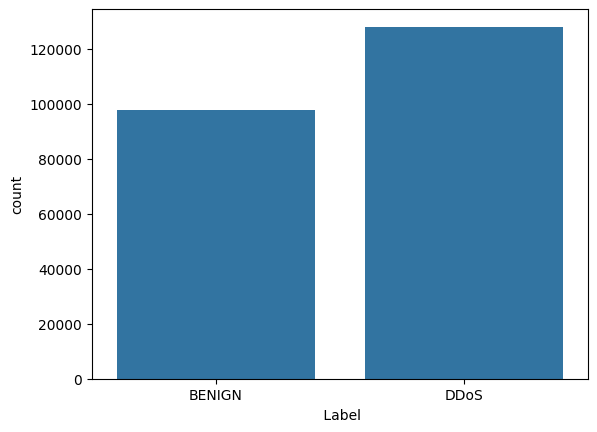

In [15]:
sns.countplot(data=df, x=df[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

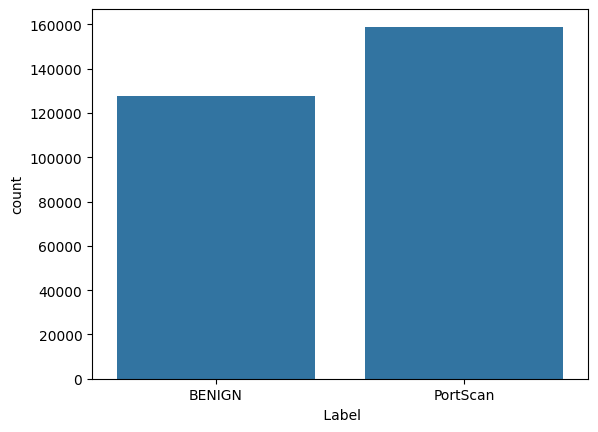

In [16]:
sns.countplot(data=df, x=df2[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

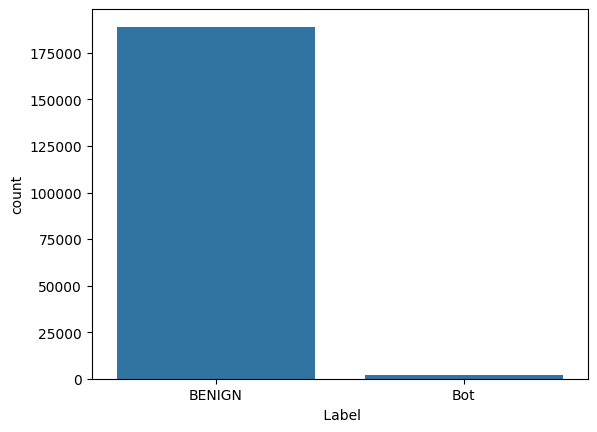

In [17]:
sns.countplot(data=df, x=df3[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

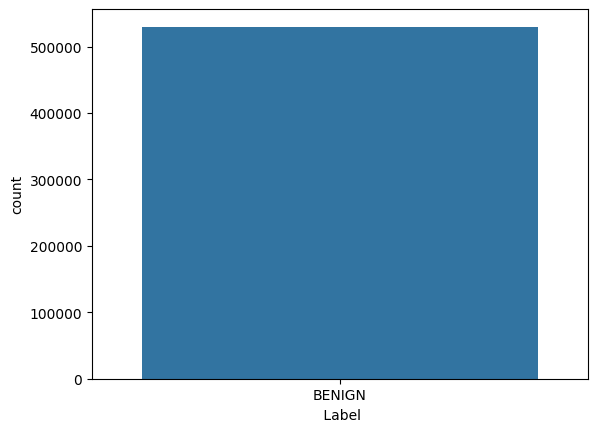

In [18]:
sns.countplot(data=df, x=df4[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

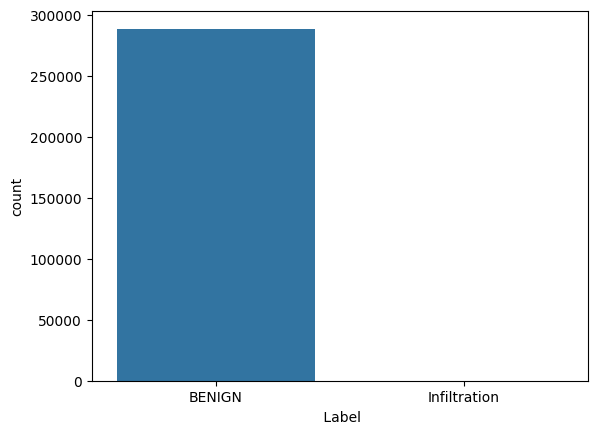

In [19]:
sns.countplot(data=df, x=df5[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

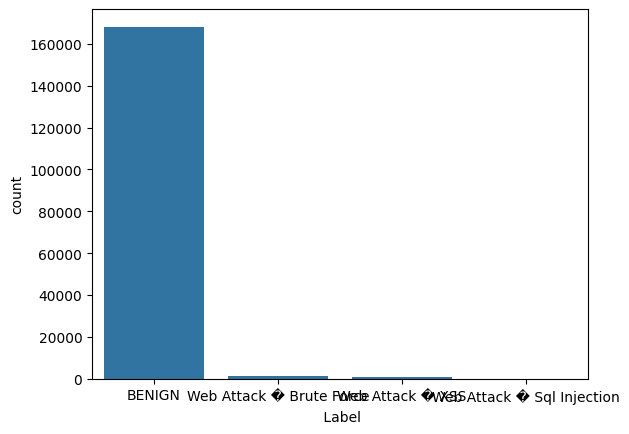

In [20]:
sns.countplot(data=df, x=df6[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

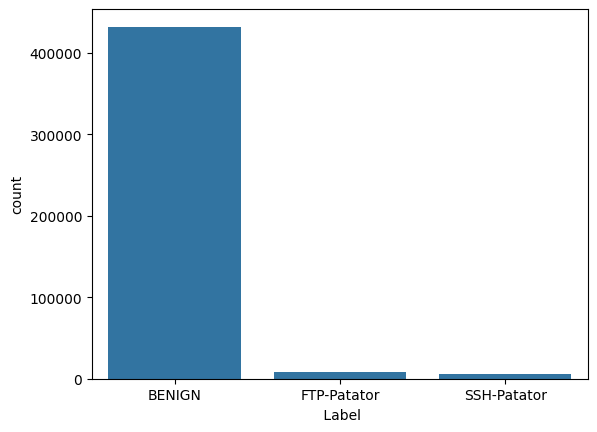

In [21]:
sns.countplot(data=df, x=df7[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

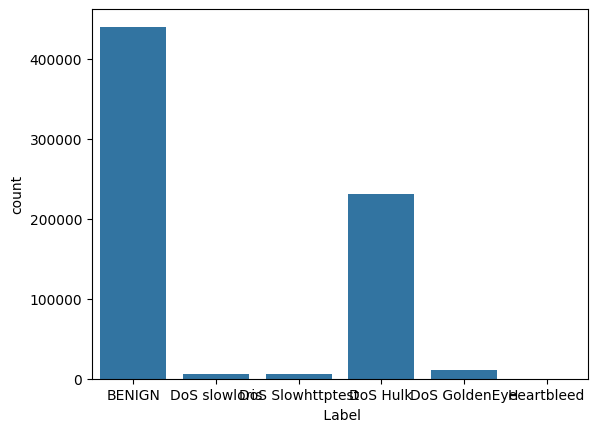

In [22]:
sns.countplot(data=df, x=df8[" Label"])

In [23]:
df_total = pd.concat([df, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)

In [24]:
df_total.shape

(2830743, 79)

In [25]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [26]:
df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
40593,53,50721,2,2,56,220,28,28,28.000000,0.000000,...,20,0.0000,0.000,0,0,0.000000e+00,0.00000,0,0,BENIGN
119837,53,83193958,2,2,136,246,94,42,68.000000,36.769553,...,32,49957.0000,0.000,49957,49957,8.310000e+07,0.00000,83100000,83100000,BENIGN
75806,80,69904,3,4,26,11601,20,0,8.666667,10.263203,...,20,0.0000,0.000,0,0,0.000000e+00,0.00000,0,0,DDoS
1304,443,22227,3,0,65,0,53,6,21.666667,27.135463,...,20,0.0000,0.000,0,0,0.000000e+00,0.00000,0,0,BENIGN
82891,80,1934929,5,0,30,0,6,6,6.000000,0.000000,...,20,0.0000,0.000,0,0,0.000000e+00,0.00000,0,0,DDoS
178281,80,6178909,4,0,24,0,6,6,6.000000,0.000000,...,20,982.0000,0.000,982,982,6.177927e+06,0.00000,6177927,6177927,DDoS
91512,80,8653600,4,0,24,0,6,6,6.000000,0.000000,...,20,806.0000,0.000,806,806,8.652794e+06,0.00000,8652794,8652794,DDoS
8072,443,117759686,23,23,2146,5183,682,0,93.304348,197.901590,...,20,707360.3636,1786845.532,5880260,23495,9.995913e+06,45902.97304,10100000,9899514,BENIGN
4792,53,171,2,2,102,158,51,51,51.000000,0.000000,...,32,0.0000,0.000,0,0,0.000000e+00,0.00000,0,0,BENIGN
30934,53,220,2,2,64,204,32,32,32.000000,0.000000,...,20,0.0000,0.000,0,0,0.000000e+00,0.00000,0,0,BENIGN


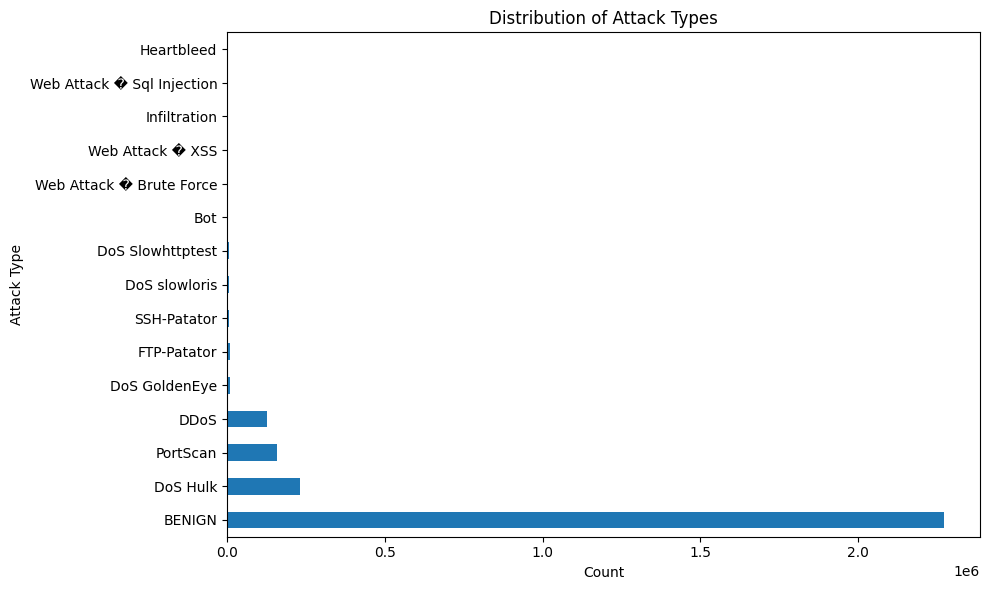

In [31]:
counts = df_total[" Label"].value_counts()

plt.figure(figsize=(10, 6))
counts.plot(kind="barh")

plt.title("Distribution of Attack Types")
plt.xlabel("Count")
plt.ylabel("Attack Type")

plt.tight_layout()
plt.show()

In [28]:
print(counts.index)

Index(['BENIGN', 'DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye',
       'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest',
       'Bot', 'Web Attack � Brute Force', 'Web Attack � XSS', 'Infiltration',
       'Web Attack � Sql Injection', 'Heartbleed'],
      dtype='object', name=' Label')


In [29]:
with open("columns.txt", "w") as f:
    for col in df_total.columns:
        f.write(col + "\n")

In [30]:
df_total.shape

(2830743, 79)